Testing gLayout current mirror¶
==============================

Simple test of current mirror elementary block

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from glayout.cells.elementary.current_mirror import current_mirror
from glayout import MappedPDK, sky130 , gf180

In [3]:
pdk=gf180
pdk.activate()

2026-05-16 23:18:00.345 | INFO     | gdsfactory.pdk:activate:337 - 'gf180' PDK is now active


In [4]:
help(current_mirror)

Help on function current_mirror in module glayout.cells.elementary.current_mirror.current_mirror:

current_mirror(pdk: glayout.pdk.mappedpdk.MappedPDK, numcols: int = 3, device: str = 'nfet', with_dummy: Optional[bool] = True, with_substrate_tap: Optional[bool] = False, with_tie: Optional[bool] = True, tie_layers: tuple[str, str] = ('met2', 'met1'), **kwargs) -> gdsfactory.component.Component
    An instantiable current mirror that returns a Component object. The current mirror is a two transistor interdigitized structure with a shorted source and gate. It can be instantiated with either nmos or pmos devices. It can also be instantiated with a dummy device, a substrate tap, and a tie layer, and is centered at the origin. Transistor A acts as the reference and Transistor B acts as the mirror fet
    
    Args:
        pdk (MappedPDK): the process design kit to use
        numcols (int): number of columns of the interdigitized fets
        device (str): nfet or pfet (can only interdigiti

In [5]:
sample_cm=current_mirror(pdk, numcols=1, width=1, length=4)
sample_cm.show()

/headless/.pyenv/versions/3.10.20/lib/python3.10/site-packages/gdsfactory/show.py:40: UserWarning: Unnamed cells, 1 in 'current_mirror'
  gdspath = component.write_gds(
2026-05-16 23:18:14.846 | WARNING  | gdsfactory.klive:show:57 - klive didn't send data, closing


In [6]:
sample_cm=current_mirror(pdk,numcols=3,width=1, length=4)
sample_cm.show()

/headless/.pyenv/versions/3.10.20/lib/python3.10/site-packages/gdsfactory/show.py:40: UserWarning: Unnamed cells, 1 in 'current_mirror$1'
  gdspath = component.write_gds(
2026-05-16 23:18:26.087 | INFO     | gdsfactory.klive:show:55 - Message from klive: {"version": "0.4.1", "klayout_version": "0.30.8", "type": "open", "file": "/tmp/gdsfactory/current_mirror$1.gds"}


In [7]:
import os
import gdstk
import svgutils.transform as sg
import IPython.display
from IPython.display import clear_output
import ipywidgets as widgets

# Redirect all outputs here
hide = widgets.Output()

def display_gds(gds_file,path,scale = 3):
  
  # Generate an SVG image
  top_level_cell = gdstk.read_gds(gds_file).top_level()[0]
  top_level_cell.write_svg(os.path.join(path,'out.svg'))
    
  # Scale the image for displaying
  fig = sg.fromfile(os.path.join(path,'out.svg'))
  fig.set_size((str(float(fig.width) * scale), str(float(fig.height) * scale)))
  fig.save(os.path.join(path,'out.svg'))

  # Display the image
  IPython.display.display(IPython.display.SVG(os.path.join(path,'out.svg')))
  os.remove(os.path.join(path,'out.gds'))

def display_component(component,path,scale = 3):
  # Save to a GDS file
  with hide:
    component.write_gds(os.path.join(path,'out.gds'))
  display_gds(os.path.join(path,'out.gds'),path,scale)

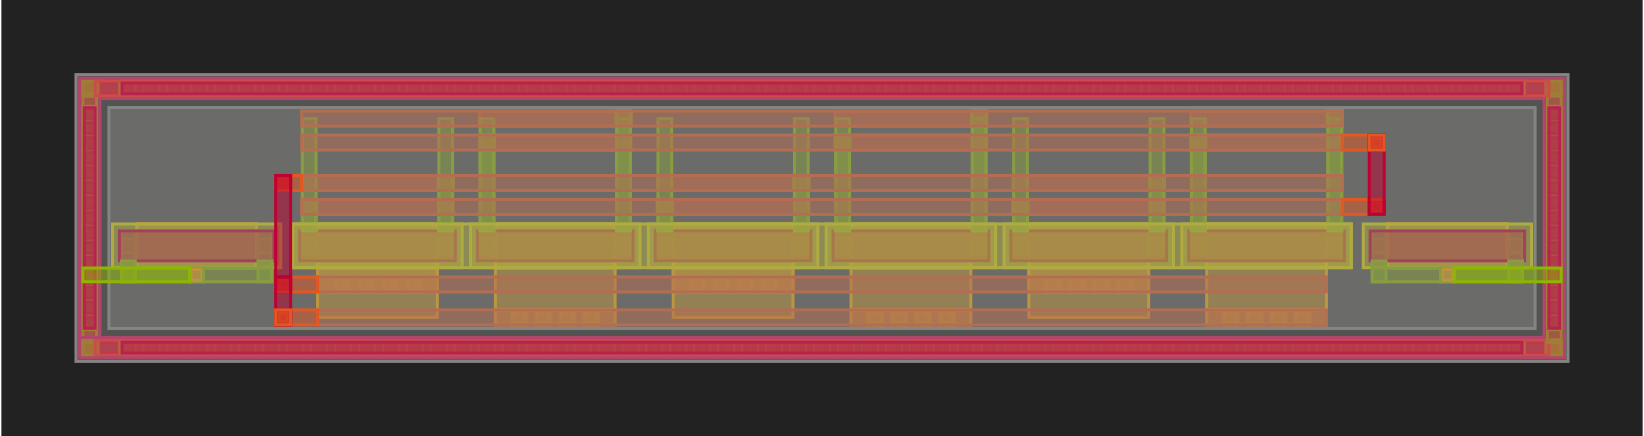

In [8]:
display_component(sample_cm,scale = 3,path="./")

In [9]:
sample_cm=current_mirror(pdk, numcols=3, width=1, length=4, device="pfet")
sample_cm.show()

/headless/.pyenv/versions/3.10.20/lib/python3.10/site-packages/gdsfactory/show.py:40: UserWarning: Unnamed cells, 1 in 'current_mirror$2'
  gdspath = component.write_gds(
2026-05-16 23:18:37.900 | INFO     | gdsfactory.klive:show:55 - Message from klive: {"version": "0.4.1", "klayout_version": "0.30.8", "type": "open", "file": "/tmp/gdsfactory/current_mirror$2.gds"}
